# 🏴‍☠️ Notebook Bônus: Completador de Frases Piratas com LSTM (PyTorch)
### Modelagem de Linguagem e Previsão da Próxima Palavra (*Next-Word Prediction*)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/allanspadini/curso-pytorch-infnet/blob/main/aula_11_lstms_grus_features_ciclicas/aula_11_lstms_grus_features_ciclicas_bonus_completador_frases_piratas_lstm.ipynb)

**Curso:** Redes Neurais Profundas e Visão Computacional — Instituto Infnet  
**Aula 11:** Modelagem Sequencial com LSTMs e GRUs  
**Autor:** Prof. Allan Spadini  

---

### 🦜 Por que este notebook existe?
Na **Aula 11**, exploramos o poder das redes neurais recorrentes (RNN, LSTM e GRU) em **séries temporais numéricas contínuas** (como previsão de passageiros aéreos e demanda de vendas em e-commerce).

No entanto, as redes recorrentes ganharam fama mundial por outra aplicação essencial: a **Modelagem de Linguagem (*Language Modeling*)** e o **Processamento de Linguagem Natural (NLP)** — o alicerce conceitual que pavimentou o caminho até os modelos gerativos e LLMs modernos!

Neste notebook bônus lúdico e minimalista, você vai aprender:
1. Como transformar texto em sequências numéricas (Tokens, Vocabulário e `nn.Embedding`).
2. Como estruturar o problema de **prever a próxima palavra (*Next-Token Prediction*)** através de janelas deslizantes de palavras.
3. Como criar e treinar uma **LSTM no PyTorch** com pouquíssimas linhas de código.
4. Como construir uma função de **Autocompletar Frases Piratas**, gerando continuações coerentes e naturais a partir de qualquer início (*prompt*)!


## 1. Importação das Bibliotecas e Configuração do Ambiente

Usaremos apenas bibliotecas fundamentais do ecossistema Python e PyTorch: `torch`, `torch.nn`, `torch.optim` e `matplotlib` para visualizações gráficas.

In [1]:
import random
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Configuração de semente para total reprodutibilidade dos resultados
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Dispositivo de Execução Selecionado: {device}")


🚀 Dispositivo de Execução Selecionado: cpu


## 2. O Dataset Fictício dos Sete Mares ⚓

Criamos um pequeno corpus com frases no clássico dialeto pirata. O objetivo da rede neural será aprender as relações sequenciais entre as palavras para conseguir autocompletar uma frase iniciada pelo usuário.

In [2]:
# Corpus fictício de frases piratas
frases_piratas = [
    "ahoy marujo icem as velas do navio",
    "homem morto nao conta historias no mar",
    "o capitao enterrou o bau do tesouro na ilha",
    "terra a vista gritou o vigia do mastro",
    "beber uma garrafa de rum com os marujos",
    "o papagaio do capitao sabe onde esta o ouro",
    "marujo jogue a ancora no mar revolto",
    "o mapa do tesouro marca o x na areia",
    "canhoes prontos para a grande batalha pirata",
    "o tesouro perdido esta escondido na caverna escura",
    "vida de pirata pelos sete mares em busca de gloria",
    "o capitao tem uma perna de pau e gancho de ferro",
    "olho de vidro e tapa olho para navegar a noite",
    "marujo prepare os canhoes para o ataque ao galeao",
    "a tempestade no oceano nao assusta o capitao destemido",
    "soltem as amarras e levantem a bandeira pirata"
]

print(f"Total de frases no dataset pirata: {len(frases_piratas)}\n")
for i, f in enumerate(frases_piratas[:6], 1):
    print(f'  {i}. "{f}"')


Total de frases no dataset pirata: 16

  1. "ahoy marujo icem as velas do navio"
  2. "homem morto nao conta historias no mar"
  3. "o capitao enterrou o bau do tesouro na ilha"
  4. "terra a vista gritou o vigia do mastro"
  5. "beber uma garrafa de rum com os marujos"
  6. "o papagaio do capitao sabe onde esta o ouro"


## 3. Tokenização e Construção do Vocabulário

Para alimentar uma rede neural com texto, precisamos mapear palavras (*strings*) em identificadores numéricos inteiros (*IDs*):
- **`word2idx`**: Dicionário que mapeia Palavra ➔ ID.
- **`idx2word`**: Dicionário reverso que mapeia ID ➔ Palavra.
- **`<PAD>`**: Token especial reservado no índice `0` para preencher sequências de tamanho variável até o comprimento fixo da janela.
- **`<FIM>`**: Token de fim de sentença (*End of Sequence*) que ensina a rede quando encerrar a frase.


In [3]:
def limpar_texto(texto):
    """Remove caracteres especiais e padroniza para minúsculas."""
    return re.sub(r'[^a-z0-9\s]', '', texto.lower()).strip()

# Tokens especiais
PAD_TOKEN = "<PAD>"
EOS_TOKEN = "<FIM>"

# Adicionamos o token de término ao final de cada frase
frases_limpas = [limpar_texto(f) + f" {EOS_TOKEN}" for f in frases_piratas]

# Extração de todas as palavras únicas
palavras_unicas = set()
for f in frases_limpas:
    palavras_unicas.update(f.split())

# Montagem da lista ordenada de vocabulário com <PAD> na posição 0
vocabulario = [PAD_TOKEN] + sorted(list(palavras_unicas))

# Mapeamentos bidirecionais
word2idx = {palavra: idx for idx, palavra in enumerate(vocabulario)}
idx2word = {idx: palavra for idx, palavra in enumerate(vocabulario)}

vocab_size = len(vocabulario)
print(f"🏴‍☠️ Tamanho do Vocabulário Pirata: {vocab_size} tokens únicos")
print(f"Primeiros 12 tokens: {vocabulario[:12]}")


🏴‍☠️ Tamanho do Vocabulário Pirata: 89 tokens únicos
Primeiros 12 tokens: ['<PAD>', '<FIM>', 'a', 'ahoy', 'amarras', 'ancora', 'ao', 'areia', 'as', 'assusta', 'ataque', 'bandeira']


## 4. Janela Deslizante de Palavras e Criação dos Tensores

Como ensinamos a rede a prever a próxima palavra?  
Quebramos cada frase em pares de **(Contexto Passado $\rightarrow$ Próxima Palavra)**.

Exemplo com a frase `["ahoy", "marujo", "icem", "as", "velas", "<FIM>"]` e janela de tamanho `SEQ_LEN = 4`:
- Entrada: `[<PAD>, <PAD>, <PAD>, "ahoy"]` $\rightarrow$ Alvo: `"marujo"`
- Entrada: `[<PAD>, <PAD>, "ahoy", "marujo"]` $\rightarrow$ Alvo: `"icem"`
- Entrada: `[<PAD>, "ahoy", "marujo", "icem"]` $\rightarrow$ Alvo: `"as"`
- Entrada: `["ahoy", "marujo", "icem", "as"]` $\rightarrow$ Alvo: `"velas"`
- Entrada: `["marujo", "icem", "as", "velas"]` $\rightarrow$ Alvo: `"<FIM>"`


In [4]:
SEQ_LEN = 4  # Tamanho fixo da janela de contexto de palavras

X_data, y_data = [], []

for f in frases_limpas:
    tokens = [word2idx[w] for w in f.split()]
    for i in range(1, len(tokens)):
        sub_seq = tokens[:i]
        # Aplica padding à esquerda para garantir tamanho fixo SEQ_LEN
        if len(sub_seq) < SEQ_LEN:
            pad_seq = [word2idx[PAD_TOKEN]] * (SEQ_LEN - len(sub_seq)) + sub_seq
        else:
            pad_seq = sub_seq[-SEQ_LEN:]
        
        target = tokens[i]
        X_data.append(pad_seq)
        y_data.append(target)

X_tensor = torch.tensor(X_data, dtype=torch.long).to(device)
y_tensor = torch.tensor(y_data, dtype=torch.long).to(device)

print(f"Total de pares de treino gerados: {len(X_tensor)}")
print(f"Shape de X (Entradas): {X_tensor.shape} (batch_size, seq_len)")
print(f"Shape de y (Rótulos):   {y_tensor.shape} (batch_size)\n")

# Visualização de alguns exemplos didáticos
print("Exemplos de pares de treino (X ➔ y):")
for i in range(5):
    contexto = [idx2word[idx.item()] for idx in X_tensor[i]]
    alvo = idx2word[y_tensor[i].item()]
    print(f'  Contexto: {contexto} ➔ Próxima Palavra: "{alvo}"')


Total de pares de treino gerados: 136
Shape de X (Entradas): torch.Size([136, 4]) (batch_size, seq_len)
Shape de y (Rótulos):   torch.Size([136]) (batch_size)

Exemplos de pares de treino (X ➔ y):
  Contexto: ['<PAD>', '<PAD>', '<PAD>', 'ahoy'] ➔ Próxima Palavra: "marujo"
  Contexto: ['<PAD>', '<PAD>', 'ahoy', 'marujo'] ➔ Próxima Palavra: "icem"
  Contexto: ['<PAD>', 'ahoy', 'marujo', 'icem'] ➔ Próxima Palavra: "as"
  Contexto: ['ahoy', 'marujo', 'icem', 'as'] ➔ Próxima Palavra: "velas"
  Contexto: ['marujo', 'icem', 'as', 'velas'] ➔ Próxima Palavra: "do"


## 5. Arquitetura da Rede: `PirateLSTM`

Nossa arquitetura em PyTorch é direta e elegante:
1. **`nn.Embedding(vocab_size, embed_dim)`**: Mapeia cada token discreto em um vetor contínuo de dimensão `embed_dim`.
2. **`nn.LSTM(embed_dim, hidden_dim, batch_first=True)`**: Processa o fluxo sequencial de vetores temporais e acumula a memória de curto e longo prazo.
3. **`nn.Linear(hidden_dim, vocab_size)`**: Camada linear final que projeta o último estado oculto da LSTM ($h_t$) no espaço do vocabulário, gerando as pontuações (*logits*) para cada palavra candidata.

```
Entrada: [token_1, token_2, token_3, token_4]
   │
   ▼
[nn.Embedding]  ➔ Tensor 3D (batch, seq_len, embed_dim)
   │
   ▼
[nn.LSTM]       ➔ Processamento Temporal Sequencial
   │
   ▼
[Último Passo]  ➔ Tensor 2D (batch, hidden_dim)
   │
   ▼
[nn.Linear]     ➔ Logits para o vocabulário (batch, vocab_size)
```


In [5]:
class PirateLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        # Camada de Embedding com padding_idx=0 (o token <PAD> não altera o gradiente)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # Camada LSTM com batch_first=True
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        
        # Camada Linear de Classificação Multiclasse
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embeds = self.embedding(x)             # (batch_size, seq_len, embed_dim)
        out, (hn, cn) = self.lstm(embeds)      # out: (batch_size, seq_len, hidden_dim)
        
        # Extrai apenas o último passo da sequência temporal (Many-to-One)
        last_step = out[:, -1, :]              # (batch_size, hidden_dim)
        
        # Gera os logits sobre todas as palavras possíveis do vocabulário
        logits = self.fc(last_step)            # (batch_size, vocab_size)
        return logits

# Instanciando o modelo
model = PirateLSTM(vocab_size=vocab_size, embed_dim=32, hidden_dim=64).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal de parâmetros treináveis: {total_params:,}")


PirateLSTM(
  (embedding): Embedding(89, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=89, bias=True)
)

Total de parâmetros treináveis: 33,721


## 6. Treinamento da Rede Neural

Como prever a próxima palavra é uma tarefa de **classificação multiclasse** entre as palavras do vocabulário, usamos:
- **Critério de Perda:** `nn.CrossEntropyLoss()`
- **Otimizador:** `optim.Adam(lr=0.01)`


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 120
historico_loss = []
historico_acc = []

print("⚓ Iniciando o treinamento da LSTM Pirata...")
model.train()

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    
    # 1. Forward pass
    logits = model(X_tensor)
    loss = criterion(logits, y_tensor)
    
    # 2. Backward pass + Otimização
    loss.backward()
    optimizer.step()
    
    # 3. Métrica de Acurácia
    with torch.no_grad():
        preds = logits.argmax(dim=1)
        acc = (preds == y_tensor).float().mean().item() * 100
        
    historico_loss.append(loss.item())
    historico_acc.append(acc)
    
    if epoch % 20 == 0 or epoch == 1:
        print(f"  [Época {epoch:03d}/{EPOCHS:03d}] Perda (Loss): {loss.item():.4f} | Acurácia: {acc:.1f}%")

print("✨ Treinamento concluído com sucesso!")


⚓ Iniciando o treinamento da LSTM Pirata...
  [Época 001/120] Perda (Loss): 4.4822 | Acurácia: 0.7%
  [Época 020/120] Perda (Loss): 0.6705 | Acurácia: 94.1%
  [Época 040/120] Perda (Loss): 0.0883 | Acurácia: 96.3%


  [Época 060/120] Perda (Loss): 0.0745 | Acurácia: 96.3%
  [Época 080/120] Perda (Loss): 0.0726 | Acurácia: 96.3%
  [Época 100/120] Perda (Loss): 0.0719 | Acurácia: 96.3%
  [Época 120/120] Perda (Loss): 0.0714 | Acurácia: 96.3%
✨ Treinamento concluído com sucesso!


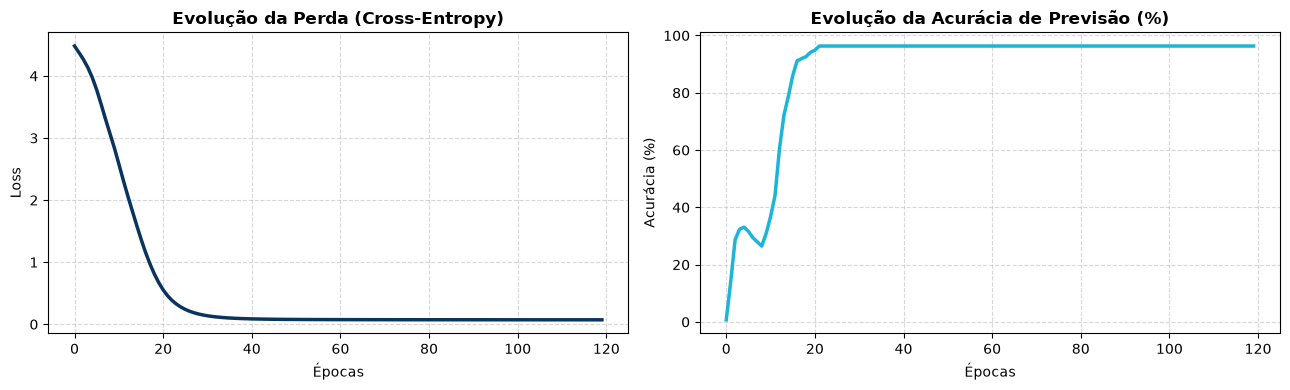

In [7]:
# Visualização da Curva de Aprendizado
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(historico_loss, color="#0A345D", lw=2.5)
axes[0].set_title("Evolução da Perda (Cross-Entropy)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(historico_acc, color="#1BB5D8", lw=2.5)
axes[1].set_title("Evolução da Acurácia de Previsão (%)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Acurácia (%)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


## 7. O Autocompletador Pirata em Ação! 🏴‍☠️

Agora construímos a função de inferência gerativa:
1. Recebe um texto inicial (*prompt*), como `"ahoy marujo"` ou `"o mapa do"`.
2. Tokeniza as palavras e aplica o padding de contexto.
3. Passa pela LSTM para obter as probabilidades da próxima palavra.
4. Concatena a palavra prevista e repete o loop até prever o token `<FIM>` ou atingir o limite máximo.


In [8]:
def autocompletar_pirata(prompt, max_palavras=12, temperatura=0.0):
    """
    Recebe um texto inicial (prompt) e autocompleta usando a LSTM treinada.
    
    Parâmetros:
      - prompt: Frase ou palavras iniciais.
      - max_palavras: Quantidade máxima de palavras para gerar.
      - temperatura: 0.0 para seleção determinística (Greedy/Argmax); > 0 para amostragem probabilística.
    """
    model.eval()
    tokens_iniciais = [limpar_texto(p) for p in prompt.split() if limpar_texto(p)]
    palavras_geradas = tokens_iniciais.copy()
    
    with torch.no_grad():
        for _ in range(max_palavras):
            # Mapeia as palavras acumuladas para seus índices
            seq_indices = [word2idx.get(w, word2idx[PAD_TOKEN]) for w in palavras_geradas]
            
            # Janelamento com padding à esquerda para tamanho SEQ_LEN
            if len(seq_indices) < SEQ_LEN:
                input_seq = [word2idx[PAD_TOKEN]] * (SEQ_LEN - len(seq_indices)) + seq_indices
            else:
                input_seq = seq_indices[-SEQ_LEN:]
                
            x_input = torch.tensor([input_seq], dtype=torch.long).to(device)
            logits = model(x_input)  # (1, vocab_size)
            
            if temperatura == 0.0:
                # Escolha determinística da palavra com maior logit
                proximo_idx = logits.argmax(dim=1).item()
            else:
                # Amostragem probabilística controlada pela temperatura
                probs = torch.softmax(logits / temperatura, dim=1)
                proximo_idx = torch.multinomial(probs, num_samples=1).item()
            
            proxima_palavra = idx2word.get(proximo_idx, PAD_TOKEN)
            
            # Encerra imediatamente se a rede prever <FIM> ou <PAD>
            if proxima_palavra in (PAD_TOKEN, EOS_TOKEN):
                break
                
            palavras_geradas.append(proxima_palavra)
            
    return " ".join(palavras_geradas)


In [9]:
# Testando o Autocompletador com Vários Inícios de Frases
prompts_teste = [
    "ahoy marujo",
    "homem morto",
    "o capitao enterrou",
    "terra a",
    "beber uma",
    "o mapa do",
    "marujo jogue",
    "canhoes prontos",
    "soltem as",
    "vida de"
]

print("=" * 75)
print("⚓ RESULTADOS DO AUTOCOMPLETADOR PIRATA (SELEÇÃO DETERMINÍSTICA)")
print("=" * 75)

for p in prompts_teste:
    resultado = autocompletar_pirata(p, max_palavras=12, temperatura=0.0)
    print(f'🦜 Prompt:  "{p}"')
    print(f'🏴‍☠️ Frase Completa:  "{resultado}"\n')


⚓ RESULTADOS DO AUTOCOMPLETADOR PIRATA (SELEÇÃO DETERMINÍSTICA)
🦜 Prompt:  "ahoy marujo"
🏴‍☠️ Frase Completa:  "ahoy marujo icem as velas do navio"

🦜 Prompt:  "homem morto"
🏴‍☠️ Frase Completa:  "homem morto nao conta historias no mar"

🦜 Prompt:  "o capitao enterrou"
🏴‍☠️ Frase Completa:  "o capitao enterrou o bau do tesouro na ilha"

🦜 Prompt:  "terra a"
🏴‍☠️ Frase Completa:  "terra a vista gritou o vigia do mastro"

🦜 Prompt:  "beber uma"
🏴‍☠️ Frase Completa:  "beber uma garrafa de rum com os marujos"

🦜 Prompt:  "o mapa do"
🏴‍☠️ Frase Completa:  "o mapa do tesouro marca o x na areia"

🦜 Prompt:  "marujo jogue"
🏴‍☠️ Frase Completa:  "marujo jogue a ancora no mar revolto"

🦜 Prompt:  "canhoes prontos"
🏴‍☠️ Frase Completa:  "canhoes prontos para a grande batalha pirata"

🦜 Prompt:  "soltem as"
🏴‍☠️ Frase Completa:  "soltem as amarras e levantem a bandeira pirata"

🦜 Prompt:  "vida de"
🏴‍☠️ Frase Completa:  "vida de pirata pelos sete mares em busca de gloria"



## 8. Experimento Bônus: Modo Criativo (*Temperature Sampling*)

O que acontece quando introduzimos **temperatura** na amostragem?
- $\text{Temperatura} \rightarrow 0$: O modelo é 100% determinístico e previsível.
- $\text{Temperatura} \in [0.7, 1.2]$: O modelo distribui probabilidades entre palavras alternativas, gerando **combinações inéditas e divertidas** de histórias piratas!


In [10]:
print("=" * 75)
print("🎲 MODO CRIATIVO (TEMPERATURA = 0.8) — HISTÓRIAS PIRATAS INÉDITAS")
print("=" * 75)

set_seed(123)
prompt_criativo = "o capitao"

for i in range(5):
    historia = autocompletar_pirata(prompt_criativo, max_palavras=10, temperatura=0.8)
    print(f'  Variação {i+1}: "{historia}"')


🎲 MODO CRIATIVO (TEMPERATURA = 0.8) — HISTÓRIAS PIRATAS INÉDITAS
  Variação 1: "o capitao tem uma perna de pau e gancho de ferro"
  Variação 2: "o capitao tem uma perna de pau e gancho de ferro"
  Variação 3: "o capitao tem uma perna de pau e gancho de ferro"
  Variação 4: "o capitao enterrou o bau do tesouro na ilha"
  Variação 5: "o capitao tem uma perna de pau e gancho de ferro"


## 9. Desafio Prático para o Aluno 🏆

Para consolidar o aprendizado deste módulo prático, experimente os seguintes desafios:
1. **Expandir o Vocabulário:** Adicione 3 a 5 novas frases piratas no dataset (ex: `"andar na prancha dos tubaroes"`, `"o bau de moedas de prata"`) e retreine a rede.
2. **Substituir a LSTM por uma GRU:** Altere a classe `PirateLSTM` para utilizar `nn.GRU`. Lembre-se de que a GRU retorna `out, hn` (sem o estado de célula `cn`). Compare o número de parâmetros!
3. **Aumentar o Contexto:** O que acontece com a precisão se alterarmos `SEQ_LEN` de `4` para `6` palavras?

---
*Bons ventos e bons códigos, marujo! ⚓🏴‍☠️*
